# Isolation-forest calibration

SHAP diagnostics, STRchive sanity checks, and the stratum-boundary diagnostic.

Needs `uv sync --group modeling` and runs against
`data/plots/02_hprc_multisample.trf.noveltyFiltered.tsv` (221k rows).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from intruder.modeling.unsupervised.isolation_forest import (
    calibrate,
    explain_by_stratum,
    explain_paths,
    feature_columns,
    fit_table,
    mean_path_length,
    plot_beeswarms,
    plot_isolation_tree,
    plot_waterfall,
    print_motif_length_dominance,
    resolve_blocks,
    score,
    stratum_boundary_shift,
)
from intruder.modeling.unsupervised.isolation_forest.features import build_features
from intruder.pipeline.strchive.catalog import Catalog

CANDIDATES_PATH = Path("../data/plots/02_hprc_multisample.trf.noveltyFiltered.tsv")
if not CANDIDATES_PATH.exists():
    CANDIDATES_PATH = Path("../data/sv_output/sniffles/first_500_INS.novelty.filtered.tsv")
print(f"using {CANDIDATES_PATH}")

using ../data/plots/02_hprc_multisample.trf.noveltyFiltered.tsv


## Fit

`intrinsic` only (single-sample capable); the same call with `--mode cohort` on the CLI
would add the `cohort` block for a multi-sample table.

In [2]:
frame = pd.read_csv(CANDIDATES_PATH, sep="\t")
blocks = resolve_blocks(["intrinsic"])
table = build_features(frame, blocks, strata_bounds=(6,))
model = fit_table(table, blocks, strata_bounds=(6,), n_jobs=1, audit="warn")

for stratum, partition in model.partitions.items():
    tag = " (pooled fallback)" if partition.fallback else ""
    print(f"{stratum:<20} n={partition.n_rows:<8}{tag}")

len<=6               n=141359  
len>6                n=80046   


## Score + SHAP, per stratum

In [3]:
scores = score(model, table.features, table.stratum)
frame = pd.concat([frame, scores, table.stratum.rename("if_stratum")], axis=1)

# explain_by_stratum() spreads TreeSHAP across every core (row-chunked joblib
# parallelism, exact since TreeSHAP is per-row independent) -- see
# visualize.py's docstring. Full population (141k / 80k rows here), no
# sampling.
shap_by_stratum = explain_by_stratum(model, table.features, table.stratum)

frame[["if_stratum", "if_score", "if_h", "if_percentile"]].describe()

,if_score,if_h,if_percentile
count,221405.000000,221405.000000,221405.000000
mean,-0.459923,11.566488,50.000452
std,0.051461,1.579831,28.867579
min,-0.751086,4.230573,0.000707
25%,-0.484538,10.709033,25.002653
50%,-0.451998,11.736542,49.999646
75%,-0.423391,12.702875,75.001249
max,-0.374473,14.517526,99.999293


## SHAP beeswarm, per stratum

- X-axis = drove that call toward looking anomalous.
- Color = Feature value high / low.
- Values are clustered by number of samples.

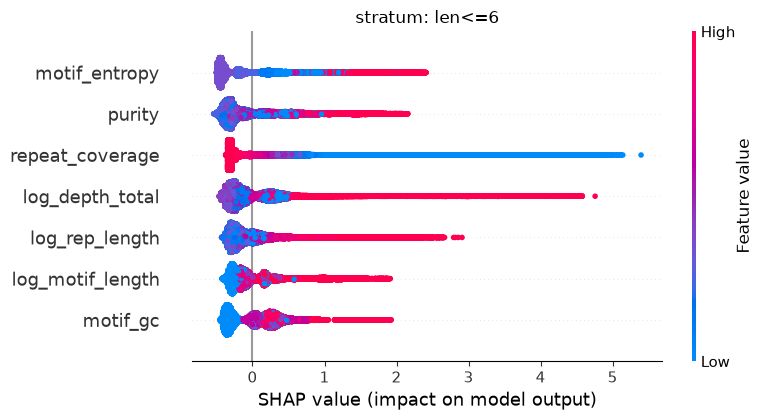

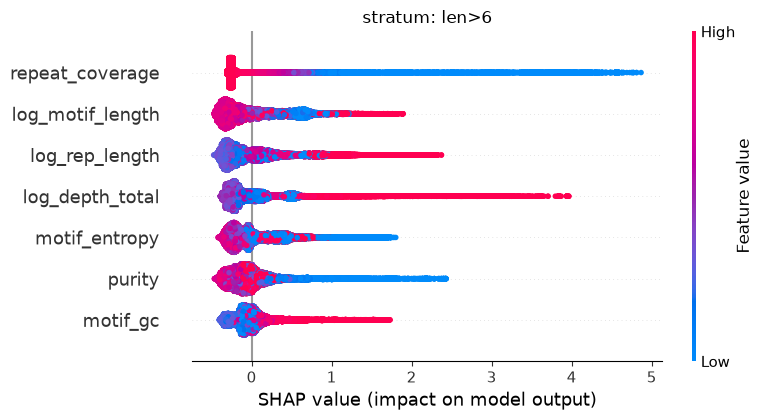

In [4]:
plot_beeswarms(shap_by_stratum)

## Per-locus waterfall

The most anomalous row in the table (lowest `if_score`).

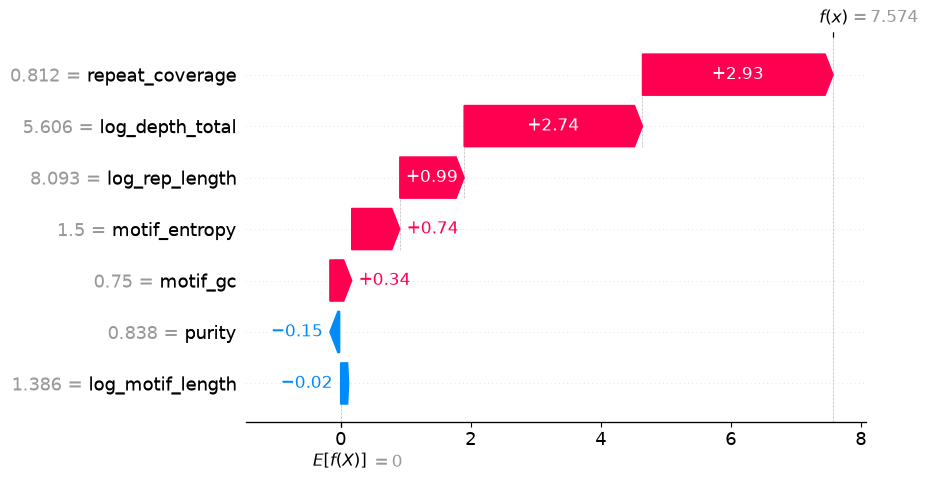

,chrom,ins_coord,SVID,depth,insert_size,sample,allele,rep_start,rep_end,motif,...,trexplorer_distance,trexplorer_motif,trexplorer_canonical,trexplorer_motif_edits,trexplorer_match,repeat_coverage,if_score,if_h,if_percentile,if_stratum
174349,chr16,33336243,Sniffles2.INS.AM992,272,4026,NA19682,1,756,4026,TGGC,...,0.0,TGGC,CTGG,0.0,exact,0.8122,-0.751086,4.230573,0.000707,len<=6


In [5]:
most_anomalous = frame["if_score"].idxmin()
row = plot_waterfall(shap_by_stratum, frame, most_anomalous)
label, partition, X = row.label, row.partition, row.X
frame.loc[[most_anomalous]]

## `explain_paths()` drill-down

The actual split sequence for that same row, tree by tree.

In [6]:
traces = explain_paths(partition.model, table.features.loc[most_anomalous], list(partition.columns))
print(f"mean h(x) across {len(traces)} trees: {mean_path_length(traces):.3f}")
print(f"actual if_h: {frame.loc[most_anomalous, 'if_h']:.3f}")
print()
shortest = min(traces, key=lambda t: len(t.steps))
print(f"shortest tree ({len(shortest.steps)} split(s) to a leaf of "
      f"{shortest.leaf_samples} sample(s)):")
for step in shortest.steps:
    print(f"  {step.feature} {'<=' if step.direction == 'left' else '>'} "
          f"{step.threshold:.4g}  (value={step.value:.4g})")

mean h(x) across 100 trees: 4.231
actual if_h: 4.231

shortest tree (1 split(s) to a leaf of 1 sample(s)):
  log_depth_total > 5.193  (value=5.606)


## Isolating tree, drawn out

The *shortest* tree above is a clean illustration of `h(x)` -- but with as few as one split, it reads as "one deciding factor," when really it's one tree's contribution to an average over all 100. This picks a typical-length trace instead and draws the tree's actual branching structure: the path this row took, highlighted in red, alongside the sibling branches (other features, other thresholds) it didn't take.


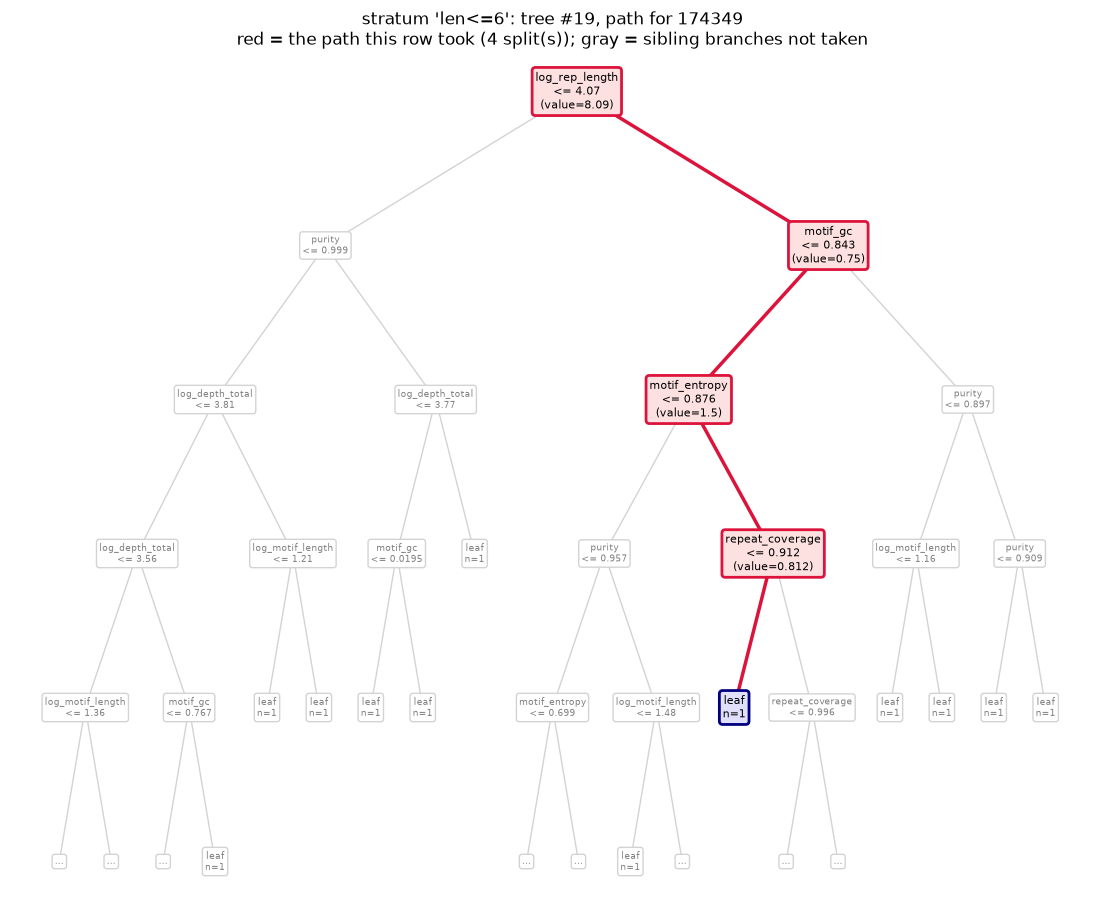

In [7]:
# The *shortest* trace above is illustrative of h(x), but with as few as
# one split it doesn't show the ensemble's branching structure -- a
# typical-length trace makes a more representative picture of one tree.
by_steps = sorted(traces, key=lambda tr: len(tr.steps))
example = by_steps[len(by_steps) // 2]

ax = plot_isolation_tree(partition.model, example, list(partition.columns))
ax.set_title(f"stratum {label!r}: tree #{example.tree_index}, path for {most_anomalous}\n"
            f"red = the path this row took ({len(example.steps)} split(s)); "
            f"gray = sibling branches not taken")
plt.show()


## STRchive sanity check

82 curated disease loci -- a sanity set, never training data. Checks whether
known-real repeats still land on the normal side of the calibration
threshold.

In [8]:
catalog = Catalog.load()
report = calibrate(frame, catalog, min_recall=0.95)
print(f"recall: {report.recall:.3f} (need >= {report.min_recall}) "
      f"at threshold {report.threshold:.4g}")
print(f"n_overlapping: {report.n_overlapping} / {report.n_strchive_loci} loci")
print(f"KS(overlap, background): statistic={report.ks_statistic:.4f} p={report.ks_pvalue:.4g}")
print(f"{len(report.dropped_loci)} STRchive locus/loci with no overlapping candidate")
report.overlap_summary, report.background_summary

recall: 0.951 (need >= 0.95) at threshold -0.5493
n_overlapping: 81 / 82 loci
KS(overlap, background): statistic=0.5776 p=3.778e-26
71 STRchive locus/loci with no overlapping candidate


({'n': 81,
  'mean': -0.5045536976950397,
  'median': -0.5018551342704626,
  'std': 0.03092533287031077},
 {'n': 221324,
  'mean': -0.45990664176417845,
  'median': -0.45198087535492854,
  'std': 0.051460030356945866})

## Empirical stratum-boundary shift

The 6bp STR/VNTR line is a convention, not a claim about where feature distributions
actually shift -- this sweeps candidate boundaries and shows the KS statistic per feature
at each one.

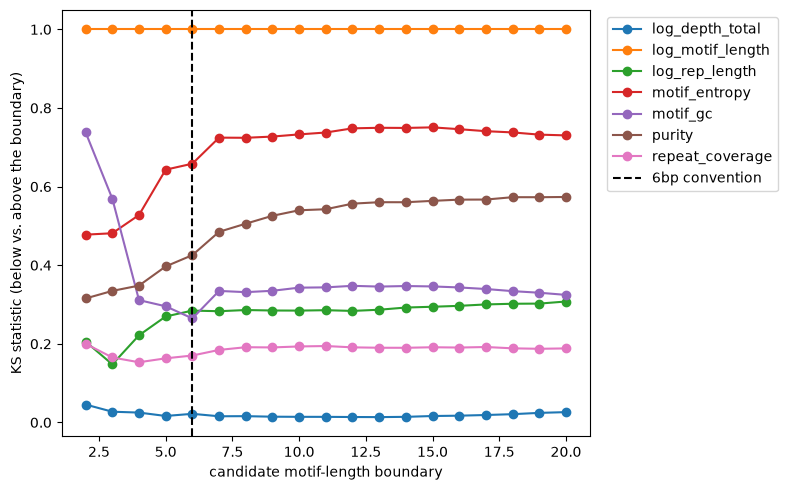

In [9]:
candidate_bounds = list(range(2, 21))
shift = stratum_boundary_shift(table.features, frame["motif_length"], candidate_bounds,
                               columns=feature_columns(blocks))

pivot = shift.pivot(index="bound", columns="feature", values="ks_statistic")
pivot.plot(marker="o", figsize=(8, 5))
plt.axvline(6, color="black", linestyle="--", label="6bp convention")
plt.xlabel("candidate motif-length boundary")
plt.ylabel("KS statistic (below vs. above the boundary)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## `log_motif_length` dominance check

If this stays high once stratified, the stratification is not doing its job.

In [10]:
print_motif_length_dominance(shap_by_stratum)

len<=6               share=0.116  dominant=False
len>6                share=0.164  dominant=False
